# [K-Mean Clustering Algorithms](#0)



## Import Required Libraries

In [32]:
import matplotlib.pyplot as plt
import random
import math
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

import warnings
warnings.filterwarnings('ignore')

In [33]:
def plot_circle(df, label_column, colors, markers, label, center_marker='x', center_colors='black'):
    for i, (color, marker) in enumerate(zip(colors, markers)):
        plt.scatter(df['x'][df[label_column] == i], df['y'][df[label_column] == i], c=color, s=30, edgecolors='k', marker=marker, linewidths=0.5, label=f'{label} {i+1}')
        plt.scatter(df['center_x'][df[label_column] == i], df['center_y'][df[label_column] == i], c=center_colors[i], marker=center_marker, label=f'{label} {i+1} Center')


In [34]:
def plot_kmeans_clusters(df, label_column, colors, markers, center_marker='x', center_colors='black'):
    for i, (color, marker) in enumerate(zip(colors, markers)):
        plt.scatter(df['x'][df[label_column] == i], df['y'][df[label_column] == i], c=color, s=30, edgecolors='k', marker=marker, linewidths=0.5, label=f'Cluster {i+1}')
        plt.scatter(df['kmeans_center_x'][df[label_column] == i], df['kmeans_center_y'][df[label_column] == i], c=center_colors[i], marker=center_marker, label=f'Cluster {i+1} Center')

In [35]:
def generate_circle_points(radius, num_points, center=(0, 0), seed=None, circle_number=0):
    random.seed(seed)
    
    x = []
    y = []

    center_x, center_y = center

    for _ in range(num_points):
        theta = random.uniform(0, 2 * math.pi)
        r = random.uniform(0, radius)
        x.append(center_x + math.sqrt(r * radius) * math.cos(theta))
        y.append(center_y + math.sqrt(r * radius) * math.sin(theta))

    return pd.DataFrame({'x': x, 'y': y, 'center_x': [center_x]*num_points, 'center_y': [center_y]*num_points, 'circle_Label': [circle_number]*num_points})

In [36]:
R1, R2, R3 = 1, 11, 22
C1, C2, C3 = (0,0), (11, 11), (21, 21)
n_points = 1000
random_seed = 42

In [37]:
# Generate points for Circle 1
df_circle1 = generate_circle_points(R1, n_points, C1, random_seed, circle_number=0)

# Generate points for Circle 2
df_circle2 = generate_circle_points(R2, n_points, C2, random_seed, circle_number=1)

# Generate points for Circle 3
df_circle3 = generate_circle_points(R3, n_points, C3, random_seed, circle_number=2)

# Concatenate all DataFrames
df_original = pd.concat([df_circle1, df_circle2, df_circle3], ignore_index=True)


In [38]:
df_original

,x,y,center_x,center_y,circle_Label
0,-0.101245,-0.121491,0,0,0
1,-0.073994,0.466622,0,0,0
2,-0.069841,-0.819647,0,0,0
3,0.229741,-0.184818,0,0,0
4,-0.152260,0.081327,0,0,0
...,...,...,...,...,...
2995,35.644980,26.423112,21,21,2
2996,16.147506,40.268987,21,21,2
2997,19.560483,8.659936,21,21,2
2998,6.266407,10.587186,21,21,2


## 1. Visualize the scatter plot of the three parts of the dataset with their points and centers.

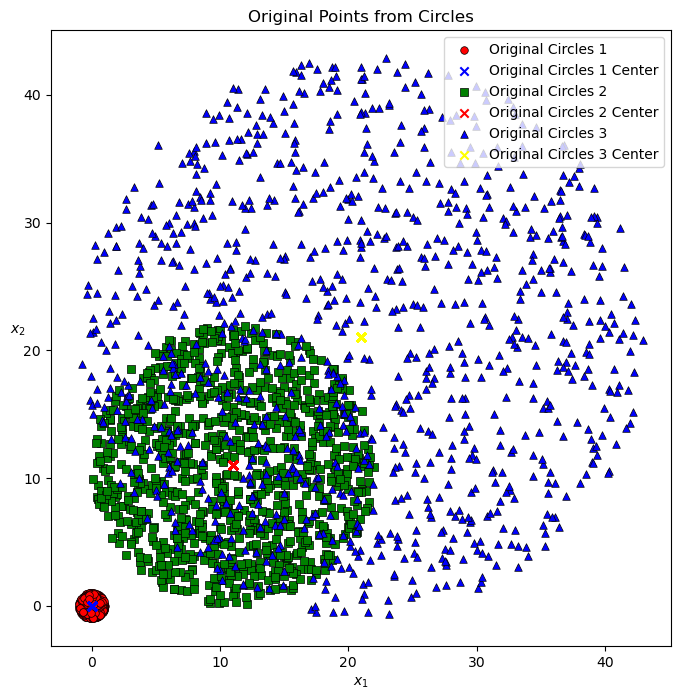

In [39]:
# Plot the original points and centers
plt.figure(figsize=(8,8))
plot_circle(df_original, 'circle_Label', ['r', 'g', 'b'], ['o', 's', '^'], 'Original Circles', center_colors=['blue', 'red', 'yellow'])

plt.xlabel("$x_1$")
plt.ylabel("$x_2$", rotation=0)
plt.legend()
plt.title("Original Points from Circles")
plt.show()

## 2. Visualize the scatter plot of the three clusters after k-means with their points and centers.

In [40]:
df_kmeans =  df_original.copy()

In [41]:
# Extract features (x, y) from the dataframe
features = df_kmeans[['x', 'y']]

# Apply k-means clustering
kmeans = KMeans(n_clusters=3, init=[C1, C2, C3], random_state=random_seed)
y_pred = kmeans.fit_predict(features)
cluster_centers = kmeans.cluster_centers_

In [42]:
y_pred is kmeans.labels_

True

In [43]:
df_kmeans['kmeans_label'] = y_pred

In [44]:
# Add cluster centers to the dataframe
df_centers = pd.DataFrame({'kmeans_center_x': cluster_centers[:, 0], 'kmeans_center_y': cluster_centers[:, 1], 'kmeans_label': range(3)})

# Merge cluster centers with the main dataframe
df_kmeans = pd.merge(df_kmeans, df_centers, on='kmeans_label')

In [45]:
cluster_centers

array([[ 0.83498093,  0.90925793],
       [12.95695638, 12.62596803],
       [26.75459681, 27.23258492]])

In [46]:
df_kmeans

,x,y,center_x,center_y,circle_Label,kmeans_label,kmeans_center_x,kmeans_center_y
0,-0.101245,-0.121491,0,0,0,0,0.834981,0.909258
1,-0.073994,0.466622,0,0,0,0,0.834981,0.909258
2,-0.069841,-0.819647,0,0,0,0,0.834981,0.909258
3,0.229741,-0.184818,0,0,0,0,0.834981,0.909258
4,-0.152260,0.081327,0,0,0,0,0.834981,0.909258
...,...,...,...,...,...,...,...,...
2995,12.295831,27.136584,21,21,2,2,26.754597,27.232585
2996,25.175250,41.015312,21,21,2,2,26.754597,27.232585
2997,35.644980,26.423112,21,21,2,2,26.754597,27.232585
2998,16.147506,40.268987,21,21,2,2,26.754597,27.232585


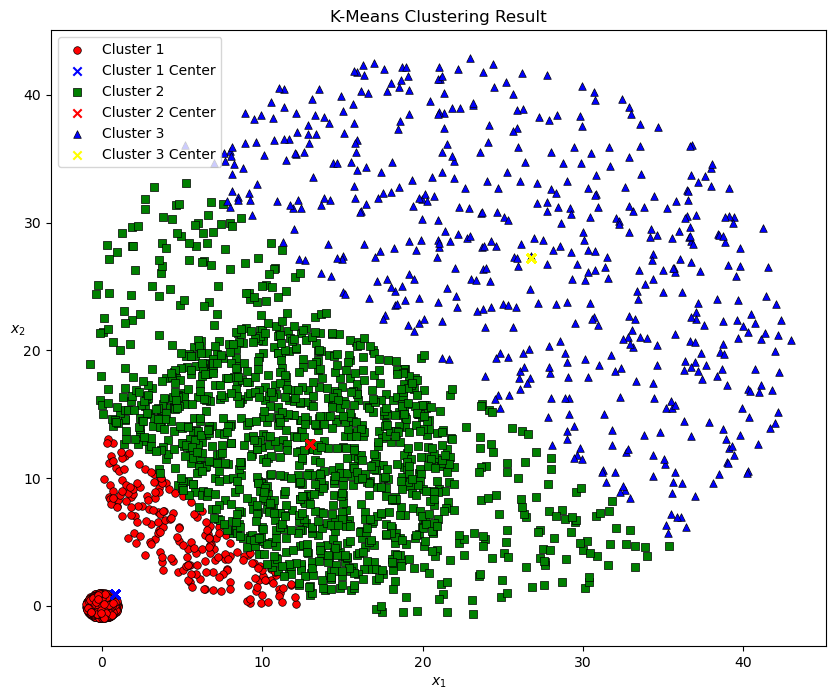

In [47]:
# Plot the k-means clustering result
plt.figure(figsize=(10, 8))
plot_kmeans_clusters(df_kmeans, 'kmeans_label', ['r', 'g', 'b'], ['o', 's', '^'], center_colors=['blue', 'red', 'yellow'])

plt.xlabel("$x_1$")
plt.ylabel("$x_2$", rotation=0)
plt.legend()
plt.title("K-Means Clustering Result")
plt.show()


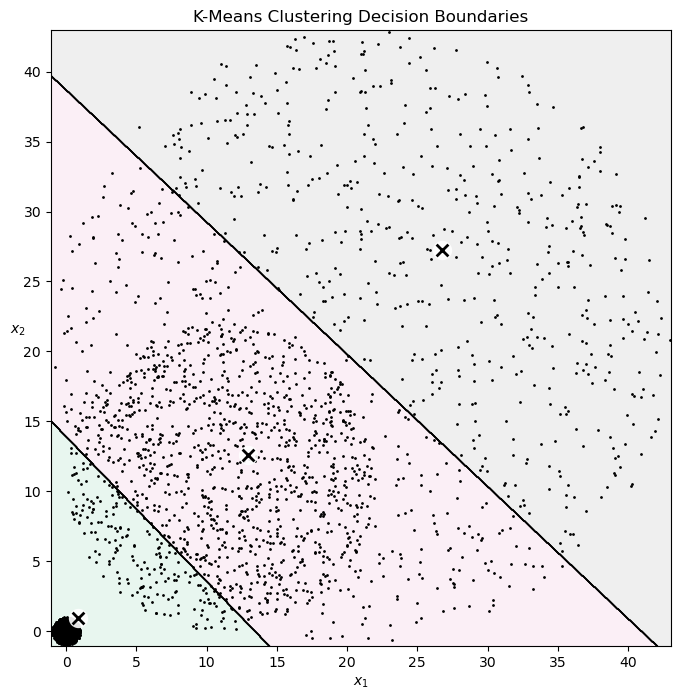

In [48]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=35, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=12,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2", alpha=0.3)  # Added alpha for better visualization
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X.to_numpy())  # Convert DataFrame to NumPy array here
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(8, 8))
plot_decision_boundaries(kmeans, features)
plt.title("K-Means Clustering Decision Boundaries")
plt.show()


## 3. Compute the accuracy of the k-means clustering.

In [49]:
true_label = df_kmeans.circle_Label
pred_label = df_kmeans.kmeans_label

# Compute the accuracy
accuracy = accuracy_score(true_label, pred_label)
print(f'Accuracy of K-Means Clustering: {accuracy * 100:.2f}%')

Accuracy of K-Means Clustering: 78.13%


## 4. Propose a clustering algorithm that can cluster them with more accurate accuracy, justify your answer.


Choosing the right clustering algorithm depends on the specific characteristics of the data. Given the circular nature of the data, a clustering algorithm like DBSCAN or Gaussian Mixture Model (GMM) might be more suitable. DBSCAN is good for detecting clusters of arbitrary shapes, and GMM can model elliptical shapes well.

## 5. Compare the mean distance of points to its center cluster result from k-mean with the mean distance of points to its centers from the original parts.

### For each cluster

In [60]:
# Calculate mean distance for k-means result
df_kmeans['kmeans_distance'] = np.sqrt((df_kmeans['x'] - df_kmeans['kmeans_center_x'])**2 + (df_kmeans['y'] - df_kmeans['kmeans_center_y'])**2)

# Calculate mean distance for each cluster in K-Means result
mean_distance_kmeans_per_cluster = df_kmeans.groupby('kmeans_label')['kmeans_distance'].mean()

# Calculate mean distance for original circles
df_kmeans['original_distance'] = np.sqrt((df_kmeans['x'] - df_kmeans['center_x'])**2 + (df_kmeans['y'] - df_kmeans['center_y'])**2)

# Calculate mean distance for each cluster in original circles
mean_distance_original_per_cluster = df_kmeans.groupby('circle_Label')['original_distance'].mean()

# Print mean distance for each cluster
print("Mean Distance for K-Means Result:")
print(mean_distance_kmeans_per_cluster)
print('-'*70)
print("\nMean Distance for Original Circles:")
print(mean_distance_original_per_cluster)


Mean Distance for K-Means Result:
kmeans_label
0     2.401132
1     8.456918
2    11.801405
Name: kmeans_distance, dtype: float64
----------------------------------------------------------------------

Mean Distance for Original Circles:
circle_Label
0     0.671945
1     7.391390
2    14.782781
Name: original_distance, dtype: float64


### For all cluster

In [50]:
# Calculate mean distance for k-means result
df_kmeans['kmeans_distance'] = np.sqrt((df_kmeans['x'] - df_kmeans['kmeans_center_x'])**2 + (df_kmeans['y'] - df_kmeans['kmeans_center_y'])**2)
mean_distance_kmeans = df_kmeans.groupby('kmeans_label')['kmeans_distance'].mean().mean()

# Calculate mean distance for original circles
df_kmeans['original_distance'] = np.sqrt((df_kmeans['x'] - df_kmeans['center_x'])**2 + (df_kmeans['y'] - df_kmeans['center_y'])**2)
mean_distance_original = df_kmeans.groupby('circle_Label')['original_distance'].mean().mean()

print(f"Mean Distance for K-Means Result: {mean_distance_kmeans:.2f}")
print(f"Mean Distance for Original Circles: {mean_distance_original:.2f}")

Mean Distance for K-Means Result: 7.55
Mean Distance for Original Circles: 7.62


In [51]:
df_kmeans

,x,y,center_x,center_y,circle_Label,kmeans_label,kmeans_center_x,kmeans_center_y,kmeans_distance,original_distance
0,-0.101245,-0.121491,0,0,0,0,0.834981,0.909258,1.392467,0.158148
1,-0.073994,0.466622,0,0,0,0,0.834981,0.909258,1.011020,0.472452
2,-0.069841,-0.819647,0,0,0,0,0.834981,0.909258,1.951363,0.822617
3,0.229741,-0.184818,0,0,0,0,0.834981,0.909258,1.250327,0.294854
4,-0.152260,0.081327,0,0,0,0,0.834981,0.909258,1.288454,0.172619
...,...,...,...,...,...,...,...,...,...,...
2995,12.295831,27.136584,21,21,2,2,26.754597,27.232585,14.459084,10.649893
2996,25.175250,41.015312,21,21,2,2,26.754597,27.232585,13.872920,20.446159
2997,35.644980,26.423112,21,21,2,2,26.754597,27.232585,8.927159,15.616837
2998,16.147506,40.268987,21,21,2,2,26.754597,27.232585,16.806491,19.870595


## 6. If the dataset is distributed into ellipses that are directed vertically, how would the clusters from K-means look like


It depends on the parameters of the ellipse, i.e., the first and second radii. Below, I will generate two sets of parameters and apply k-means to both. Afterward, I will plot the distribution for each cluster.

In [52]:
def generate_ellipse_points(a, b, num_points, center=(0, 0), seed=None, ellipse_number=0):
    random.seed(seed)
    
    x = []
    y = []

    center_x, center_y = center

    for _ in range(num_points):
        theta = random.uniform(0, 2 * math.pi)
        u = random.uniform(0, 1)
        x.append(center_x + a * math.cos(theta) * math.sqrt(u))
        y.append(center_y + b * math.sin(theta) * math.sqrt(u))

    return pd.DataFrame({'x': x, 'y': y, 'center_x': [center_x]*num_points, 'center_y': [center_y]*num_points, 'ellipse_Label': [ellipse_number]*num_points})


In [53]:
# First set of Parameters
a1, b1 = 1, 2  # Parameters for Ellipse 1
a2, b2 = 5, 10  # Parameters for Ellipse 2
a3, b3 = 11, 22  # Parameters for Ellipse 3

# Second set of Parameters
a4, b4 = 1, 5  # Parameters for Ellipse 1
a5, b5 = 2, 8  # Parameters for Ellipse 2
a6, b6 = 3, 10  # Parameters for Ellipse 3

In [54]:
# Generate points for Ellipse 1
df_ellipse1 = generate_ellipse_points(a1, b1, n_points, C1, random_seed, ellipse_number=0)
df_ellipse4 = generate_ellipse_points(a4, b4, n_points, C1, random_seed, ellipse_number=0)

# Generate points for Ellipse 2
df_ellipse2 = generate_ellipse_points(a2, b2, n_points, C2, random_seed, ellipse_number=1)
df_ellipse5 = generate_ellipse_points(a5, b5, n_points, C2, random_seed, ellipse_number=1)

# Generate points for Ellipse 3
df_ellipse3 = generate_ellipse_points(a3, b3, n_points, C3, random_seed, ellipse_number=2)
df_ellipse6 = generate_ellipse_points(a6, b6, n_points, C3, random_seed, ellipse_number=2)

# Concatenate all DataFrames
df_ellipses_set1 = pd.concat([df_ellipse1, df_ellipse2, df_ellipse3], ignore_index=True)
df_ellipses_set2 = pd.concat([df_ellipse4, df_ellipse5, df_ellipse6], ignore_index=True)

### K-Means for First set of Parameters

In [55]:
# Apply K-Means clustering
df_kmeans_ellipses_set2 = df_ellipses_set2.copy()
features_ellipses_set2 = df_kmeans_ellipses_set2[['x', 'y']]
kmeans_ellipses = KMeans(n_clusters=3, random_state=random_seed)
y_pred_ellipses_set2 = kmeans_ellipses.fit_predict(features_ellipses_set2)
cluster_centers_ellipses = kmeans_ellipses.cluster_centers_

df_kmeans_ellipses_set2['kmeans_label'] = y_pred_ellipses_set2

# Add cluster centers to the dataframe
df_centers_ellipses = pd.DataFrame({'kmeans_center_x': cluster_centers_ellipses[:, 0], 'kmeans_center_y': cluster_centers_ellipses[:, 1], 'kmeans_label': range(3)})

# Merge cluster centers with the main dataframe
df_kmeans_ellipses_set2 = pd.merge(df_kmeans_ellipses_set2, df_centers_ellipses, on='kmeans_label')


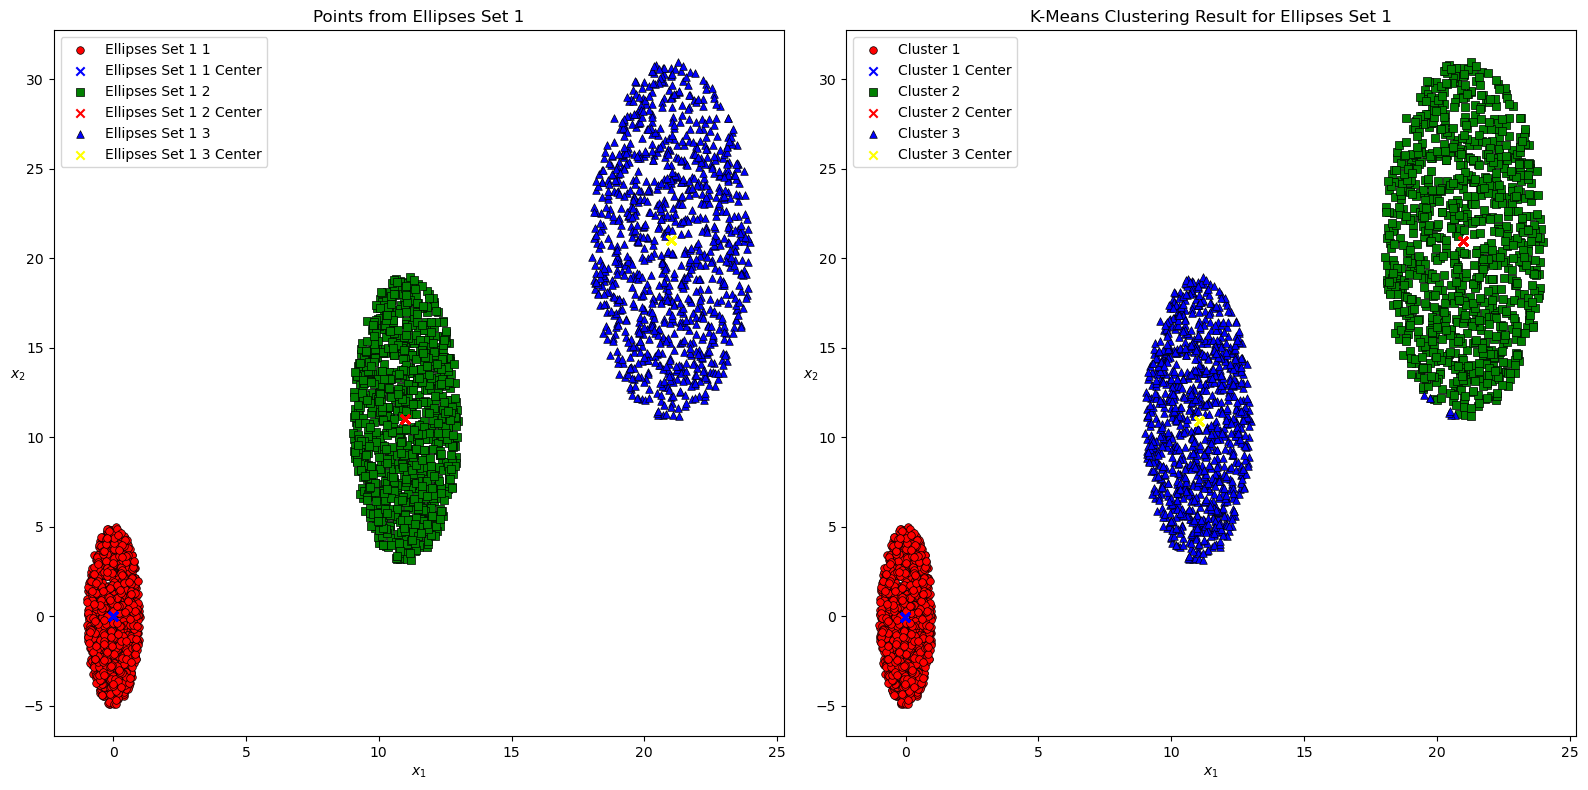

In [56]:
# Plot the points
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_circle(df_ellipses_set2, 'ellipse_Label', ['r', 'g', 'b'], ['o', 's', '^'], 'Ellipses Set 1', center_colors=['blue', 'red', 'yellow'])

plt.xlabel("$x_1$")
plt.ylabel("$x_2$", rotation=0)
plt.legend()
plt.title("Points from Ellipses Set 1")

# Plot the K-Means clustering result for ellipses
plt.subplot(1, 2, 2)
plot_kmeans_clusters(df_kmeans_ellipses_set2, 'kmeans_label', ['r', 'g', 'b'], ['o', 's', '^'], center_colors=['blue', 'red', 'yellow'])

plt.xlabel("$x_1$")
plt.ylabel("$x_2$", rotation=0)
plt.legend()
plt.title("K-Means Clustering Result for Ellipses Set 1")

plt.tight_layout()
plt.show()


### K-Means for Second set of Parameters

In [57]:
# Apply K-Means clustering
df_kmeans_ellipses_set1 = df_ellipses_set1.copy()
features_ellipses_set1 = df_kmeans_ellipses_set1[['x', 'y']]
kmeans_ellipses = KMeans(n_clusters=3, random_state=random_seed)
y_pred_ellipses_set1 = kmeans_ellipses.fit_predict(features_ellipses_set1)
cluster_centers_ellipses = kmeans_ellipses.cluster_centers_

df_kmeans_ellipses_set1['kmeans_label'] = y_pred_ellipses_set1

# Add cluster centers to the dataframe
df_centers_ellipses = pd.DataFrame({'kmeans_center_x': cluster_centers_ellipses[:, 0], 'kmeans_center_y': cluster_centers_ellipses[:, 1], 'kmeans_label': range(3)})

# Merge cluster centers with the main dataframe
df_kmeans_ellipses_set1 = pd.merge(df_kmeans_ellipses_set1, df_centers_ellipses, on='kmeans_label')


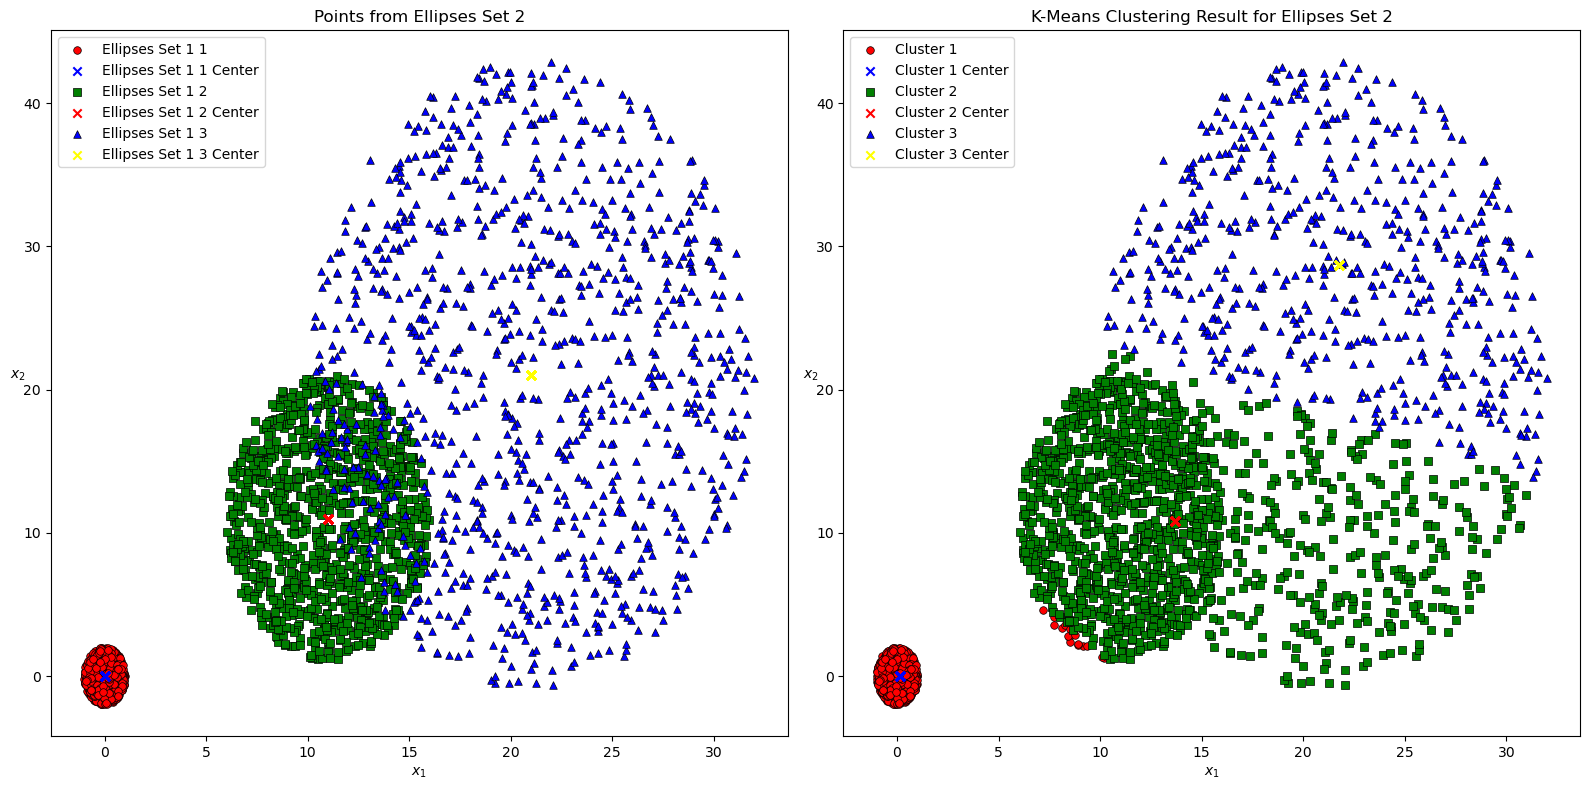

In [58]:
# Plot the points
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_circle(df_ellipses_set1, 'ellipse_Label', ['r', 'g', 'b'], ['o', 's', '^'], 'Ellipses Set 1', center_colors=['blue', 'red', 'yellow'])

plt.xlabel("$x_1$")
plt.ylabel("$x_2$", rotation=0)
plt.legend()
plt.title("Points from Ellipses Set 2")

# Plot the K-Means clustering result for ellipses
plt.subplot(1, 2, 2)
plot_kmeans_clusters(df_kmeans_ellipses_set1, 'kmeans_label', ['r', 'g', 'b'], ['o', 's', '^'], center_colors=['blue', 'red', 'yellow'])

plt.xlabel("$x_1$")
plt.ylabel("$x_2$", rotation=0)
plt.legend()
plt.title("K-Means Clustering Result for Ellipses Set 2")

plt.tight_layout()
plt.show()
